In [9]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import tifffile
from PIL import Image
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.transforms as mtransforms
import cmcrameri.cm as cm

import analysis_functions as afn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
with Image.open('data_shot3_raw/streak/z4290leg1_laserstreak_preshot-nr.tif') as img:
    streak_pre_nr = np.array(img)
with Image.open('data_shot3_raw/streak/z4290leg1_laserstreak_preshot-r.tif') as img:
    streak_pre_r = np.array(img)   
with Image.open('data_shot3_raw/streak/z4290leg1_laserstreak.tif') as img:
    streak = np.array(img)   

calib = pd.read_csv('streak_calib.csv')

In [3]:
px_to_mm = calib['value'].values[0]
px_to_ns = calib['value'].values[1]

cmax = np.percentile(streak, 99)

Text(0, 0.5, 'mm')

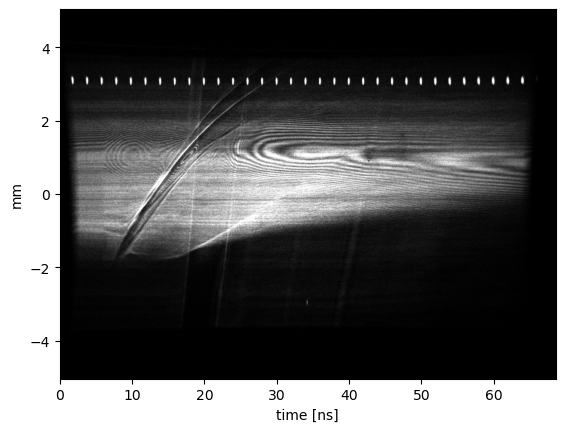

In [4]:
extent_x = streak.shape[1] * px_to_ns
extent_y = streak.shape[0] * px_to_mm
ext=[0, extent_x, -extent_y/2, extent_y/2]

plt.imshow(streak, cmap = 'grey', extent=ext, aspect='auto')
plt.clim(0, cmax)
plt.xlabel('time [ns]')
plt.ylabel('mm')

In [10]:
times = np.linspace(6, 36, 16)
times = np.array(times)
for t in times:
    afn.plot_vlineout_streak(t_ns = t, ext = ext, image =streak, output = f'streak_images/lineouts/linout_t={t}ns.jpg')